# leveraging AVISO while gaussian filtering SWOT data

In [62]:
import xarray as xr
import pandas as pd
import numpy as np

import os
from glob import glob

import matplotlib.pyplot as plt

from numba import njit, prange
#, int32, float64

from cstes import zarr_dir, version_swot, swot_dir_2km


import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from altimetry_filter import define_eta
from diagnosis import put_fig_letter

## Example data

In [5]:
L4_dir = {'L4_noswot_regional' :'/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/regional-europe/dt-grids/all-sat-merged/2023/*.nc', 
          'L4_noswot_global':'/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/global/dt-grids/all-sat-merged/2023/*.nc', 
          'L4_withnadirswot' :'/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/*/*.nc',
         }
L4_key = 'L4_withnadirswot'

In [6]:
swot = xr.open_zarr(swot_dir_2km, "3_500.zarr")
#swot = xr.open_zarr(swot_dir_2km, "16_538.zarr")

#correct SWOT product time
if version_swot == '2.0.1' : swot['time'] = (swot.time - np.timedelta64(946684800000000000, 'ns'))
swot = swot.where(swot["latitude_nadir"].compute()>36, drop=True)
swot = swot.where(swot.duacs_editing_flag==0)
define_eta(swot, mean_sla=False)
swot["adt"] = swot["duacs_mean_dynamic_topography"] + swot["duacs_ssha_karin_2_filtered"]


#aviso = xr.open_dataset( "dt_europe_allsat_phy_l4_20230601_20231013.nc")
aviso = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', L4_key+'.nc'))
# select only area where swath is ... adjust for swath 16
aviso = aviso.sel(longitude=slice(swot.longitude.min()-1,swot.longitude.max()+1), latitude=slice(swot.latitude.min()-1, swot.latitude.max()+1))
aviso = aviso.interp(time = swot.time.mean().compute().values)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/zarr.py:1103: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = open_dataset(


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


Text(0.5, 1.0, '')

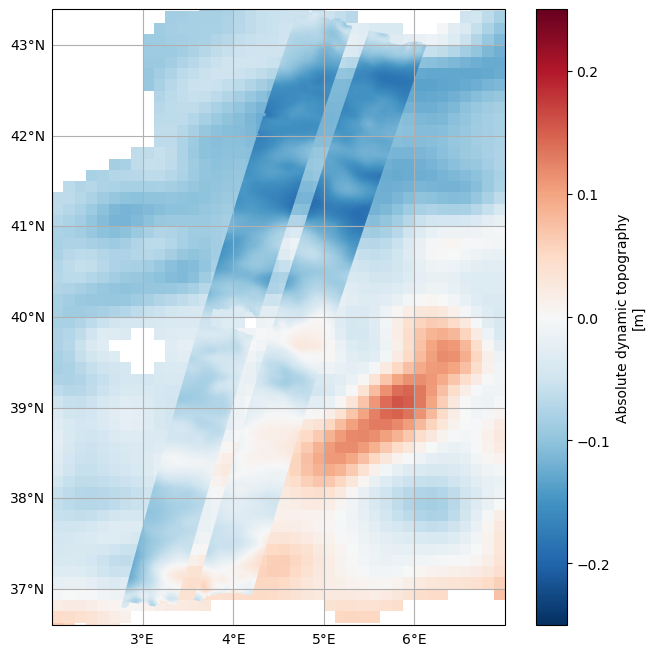

In [7]:
bbox = [2, 7, 36.6, 43.4]

fig = plt.figure(figsize=(8,8), frameon=False)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu_r",transform =crs,)
#kw = dict(cmap="RdBu_r")
aviso["adt"].assign_attrs({'longname': 'DSL [m]'}).plot( **kw,)
im = ax.scatter(swot.longitude, swot.latitude, c=swot["adt"], s=1, **kw,)
#ax.set_aspect(np.cos(np.deg2rad(40)))

ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

ax.set_title('')


In [11]:
swot = swot[["adt"]].compute()

swot["mask"] = xr.where(
    (~np.isnan(swot.longitude)) 
    & (~np.isnan(swot.latitude))
    & (~np.isnan(swot.adt)),
    1, 0,
)
dl=2e3

In [26]:
from altimetry_filter import apply_gaussian_filter_nb, apply_gaussian_filter_aviso
cutoff = 40e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl).where(swot.mask)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"]).where(swot.mask)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


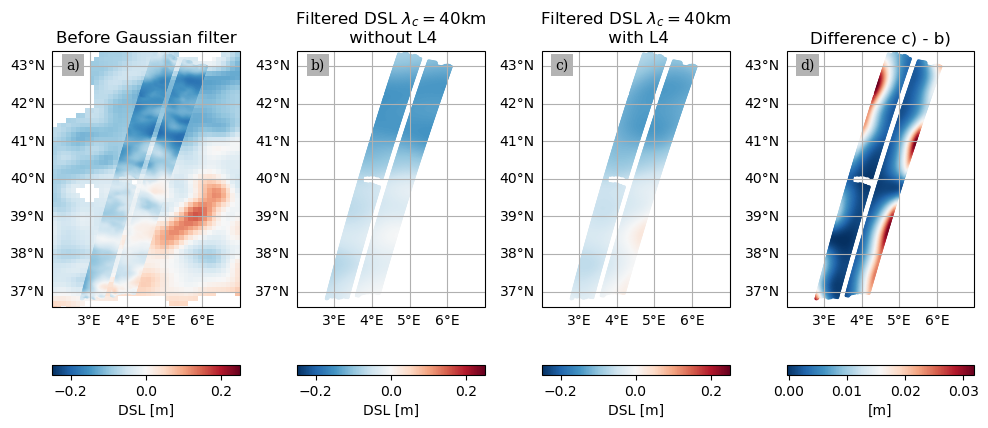

In [79]:
bbox = [2, 7, 36.6, 43.4]

fig, axs = plt.subplots(1, 4, figsize=(10,4.5), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), sharey=True)

ax=axs[0]
kw = dict(vmin=-.25, vmax=.25, cmap="RdBu_r",transform =crs,)
#kw = dict(cmap="RdBu_r")
aviso["adt"].assign_attrs({'longname': 'DSL [m]'}).plot(ax=ax, add_colorbar=False, **kw,)
im = ax.scatter(swot.longitude, swot.latitude, c=swot["adt"], s=1, **kw,)
#ax.set_aspect(np.cos(np.deg2rad(40)))
#plt.colorbar(im, location="bottom")
ax.set_title('Before Gaussian filter')
plt.colorbar(im,location='bottom', label=r'DSL [m]' )
put_fig_letter(fig, ax, 'a')

ax = axs[1]
im = ax.scatter(daf.longitude, daf.latitude, c=daf, s=1, **kw)
ax.set_title(rf'Filtered DSL $\lambda_c = {round(cutoff/1000)}$km'+'\n without L4')
plt.colorbar(im,location='bottom', label='DSL [m]' )
put_fig_letter(fig, ax, 'b')

ax = axs[2]
im = ax.scatter(daf_aviso.longitude, daf_aviso.latitude, c=daf_aviso, s=1, **kw)
ax.set_title(rf'Filtered DSL $\lambda_c = {round(cutoff/1000)}$km'+'\n with L4')
plt.colorbar(im,location='bottom', label='DSL [m]' )
put_fig_letter(fig, ax, 'c')


ax = axs[3]
im = ax.scatter(daf.longitude, daf.latitude, c=(daf_aviso-daf), s=1, cmap="RdBu_r",)
ax.set_title('Difference c) - b)')
plt.colorbar(im,location='bottom', label=r'[m]' )
put_fig_letter(fig, ax, 'd')


for ax in axs :
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    
#ax.colorbar(im,location='bottom' )
fig.tight_layout()

---
# wrapped methods and example

In [202]:
cutoff = 20e3

# Using wrapper
from altimetry_filter import define_eta, add_grid_metrics
f = os.path.join(swot_dir_2km, "3_538.zarr")
d =  filter_diff_one(f, filter_diff_method = 'gaussian_aviso', filter_diff_kwargs = {'cutoff': cutoff}, mean_sla=False, distance_to_coast_min=None)

# with function
swot = xr.open_zarr(swot_dir_2km, "3_538.zarr")

#correct SWOT product time
if version_swot == '2.0.1' : swot['time'] = (swot.time - np.timedelta64(946684800000000000, 'ns'))
#swot = swot.where(swot["latitude_nadir"].compute()>36, drop=True)
swot = swot.where(swot.duacs_editing_flag==0)
define_eta(swot, mean_sla=False)
swot["adt"] = swot["duacs_mean_dynamic_topography"] + swot["duacs_ssha_karin_2_filtered"]
dl=2000
aviso = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', L4_key+'.nc'))
# select only area where swath is ... adjust for swath 16
aviso = aviso.sel(longitude=slice(swot.longitude.min()-1,swot.longitude.max()+1), latitude=slice(swot.latitude.min()-1, swot.latitude.max()+1))
aviso = aviso.interp(time = swot.time.mean().compute().values)
swot = swot.compute()
swot["mask"] = xr.where(
    (~np.isnan(swot.longitude)) 
    & (~np.isnan(swot.latitude))
    & (~np.isnan(swot.adt)),
    1, 0,
)

daf = apply_gaussian_filter_nb(swot["etaf"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["etaf"], cutoff, swot["mask"], dl, aviso["adt"])



/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


2000.0 2000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/zarr.py:1103: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = open_dataset(


## Check same with filter_diff_one

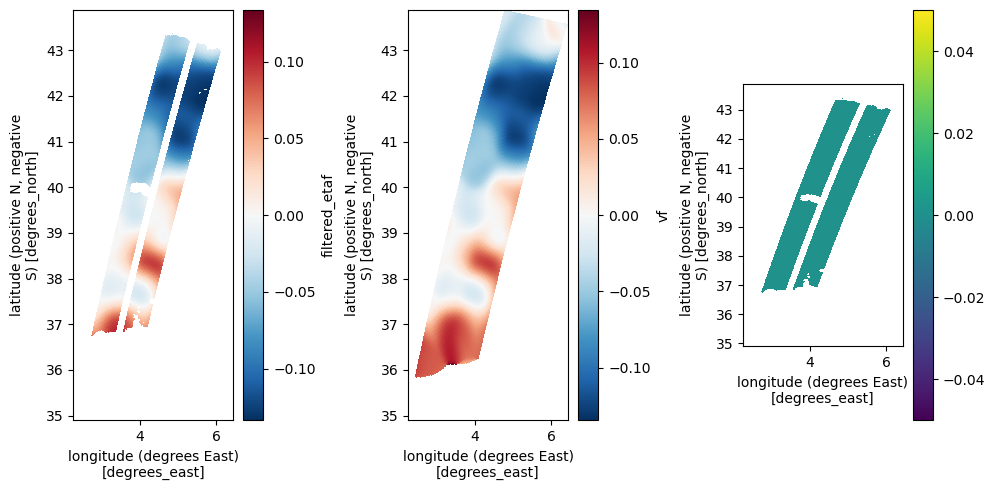

In [207]:
fig, axs = plt.subplots(1,3, figsize =(10, 5))
ax=axs[0]
d.filtered_etaf.plot(x='longitude', y='latitude', ax=ax)
ax=axs[1]
daf_aviso.plot(x='longitude', y='latitude',ax=ax)
ax=axs[2]
(d.filtered_etaf- daf_aviso).plot(x='longitude', y='latitude',ax=ax)
ax.set_aspect(np.cos(np.deg2rad(40)))
fig.tight_layout()

In [43]:
swot = swot[["adt"]].compute()

swot["mask"] = xr.where(
    (~np.isnan(swot.longitude)) 
    & (~np.isnan(swot.latitude))
    & (~np.isnan(swot.adt)),
    1, 0,
)

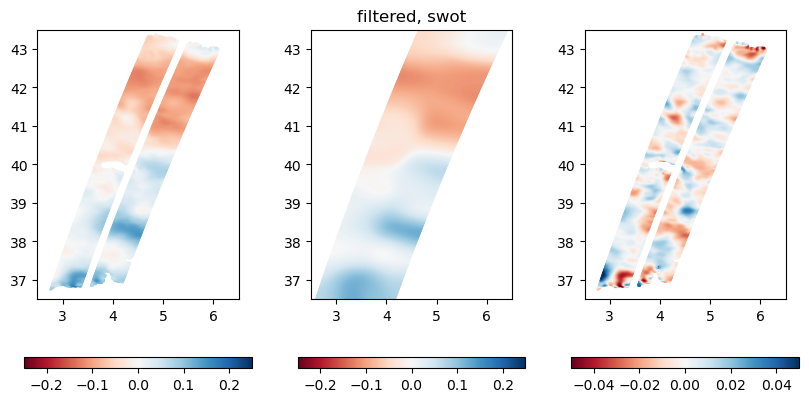

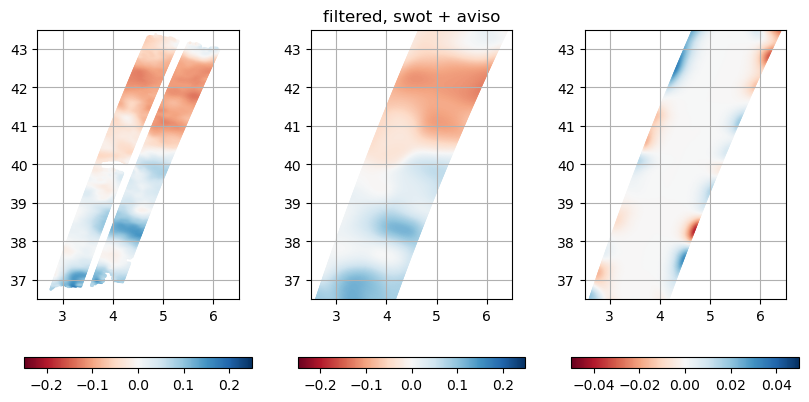

In [52]:
cutoff = 20e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso -daf# swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()



In [54]:
daf

<xarray.DataArray 'vf' (num_lines: 441, num_pixels: 69)> Size: 243kB
array([[ 0.0835345 ,  0.08354544,  0.08355647, ...,         nan,
                nan,         nan],
       [ 0.08299359,  0.08300392,  0.08301436, ...,         nan,
                nan,         nan],
       [ 0.082105  ,  0.0821082 ,  0.08211136, ...,         nan,
                nan,         nan],
       ...,
       [-0.04365815, -0.04316203, -0.04265052, ...,  0.02142632,
         0.02167931,  0.02184999],
       [-0.04340266, -0.04291574, -0.04241511, ...,  0.02192631,
         0.02217272,  0.02237255],
       [-0.04314649, -0.04266918, -0.04217935, ...,  0.02250998,
         0.02278421,  0.02299332]])
Coordinates:
  * num_lines        (num_lines) int64 4kB 0 1 2 3 4 5 ... 436 437 438 439 440
  * num_pixels       (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 63 64 65 66 67 68
    latitude         (num_lines, num_pixels) float64 243kB 36.13 36.13 ... 43.57
    latitude_nadir   (num_lines, num_pixels) float64 243kB 36.01 36.01 ... 43.72
    longitude        (num_lines, num_pixels) float64 243kB 2.514 2.536 ... 6.423
    longitude_nadir  (num_lines, num_pixels) float64 243kB 3.242 3.242 ... 5.596
    time             (num_lines, num_pixels) datetime64[ns] 243kB 2023-05-31T...
    weight0          (num_lines, num_pixels) float64 243kB 0.0001955 ... 0.00...

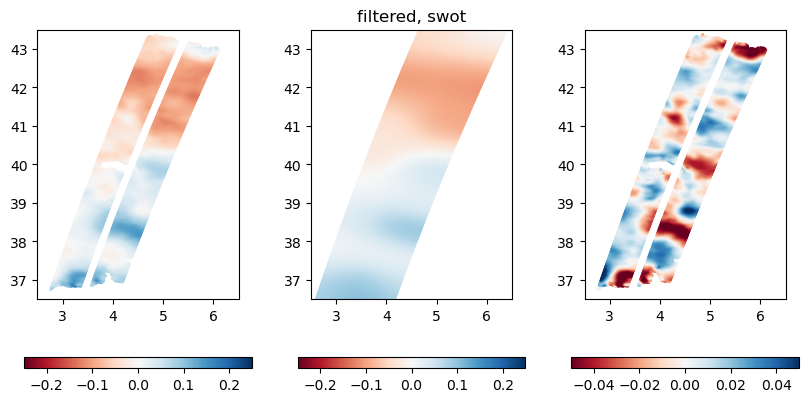

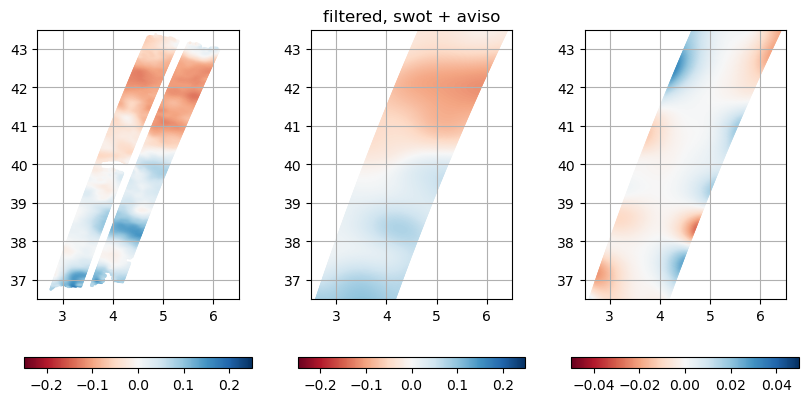

In [50]:
cutoff = 40e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso - daf#swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

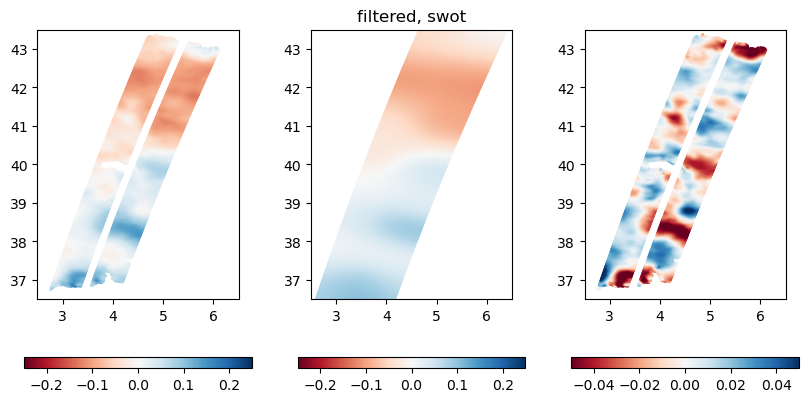

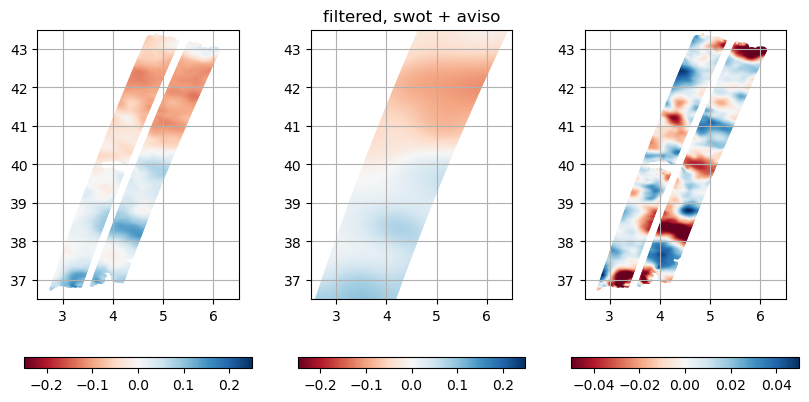

In [49]:
cutoff = 40e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

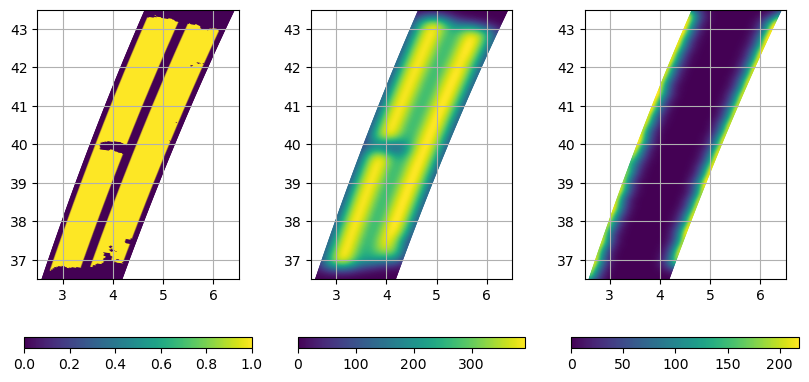

In [53]:
fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf["weight0"]
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso["weight1"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

## !! units: dx, sigma, doivent être en metre ou sinon il faut ajuster code